# Notebook 01 — Advanced RAG Pipeline Demo

Comparing 4 retrieval strategies on SecureBank's policy documents:
1. **Baseline** — flat FAISS similarity search
2. **Hybrid** — BM25 + FAISS via Reciprocal Rank Fusion
3. **Reranked** — Hybrid + Cross-Encoder reranking
4. **Full Pipeline** — Contextual Retrieval + Multi-HyDE + Hybrid + Reranking + CRAG

Papers:
- Contextual Retrieval: Anthropic (2024)
- Multi-HyDE: arxiv:2509.16369 (ACL FinNLP 2025)
- CRAG: arxiv:2401.15884 (ICLR 2025)

In [1]:
import sys, os

_cwd = os.path.abspath(os.getcwd())
_root = _cwd if os.path.exists(os.path.join(_cwd, 'main.py')) else os.path.dirname(_cwd)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.retrievers import EnsembleRetriever
from sentence_transformers import CrossEncoder
import time

print('Libraries loaded ✓')
print(f'Project root: {_root}')

/Users/aliiii/Desktop/projects/Secure-Financial-AI-Agent/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/aliiii/Desktop/projects/Secure-Financial-AI-Agent/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded ✓
Project root: /Users/aliiii/Desktop/projects/Secure-Financial-AI-Agent


In [2]:
# Load and split the bank policy document
loader = TextLoader('data/bank_policies.txt')
docs = loader.load()
full_text = docs[0].page_content
print('Policy document loaded:')
print('─' * 50)
print(full_text)
print('─' * 50)

Policy document loaded:
──────────────────────────────────────────────────
SecureBank Internal Policy Document

Mortgage Conditions:
To qualify for a standard mortgage at SecureBank, the applicant must have a minimum credit score of 700. The maximum loan term allowed is 25 years. The standard fixed interest rate for 2026 is 5%

Account Overdraft Rules:
If a customer's account balance falls below $0, a standard overdraft fee of $35 will be applied immediately. SecureBank does not waive overdraft fees under any circumstances.

Investment Restrictions:
SecureBank strictly prohibits its advisors from recommending or facilitating the purchase of cryptocurrencies, meme stocks, or high-frequency day trading algorithms. Advisors must only recommend approved mutual funds and government bonds.

Personal Loan Policy:
SecureBank offers personal loans to existing customers who have maintained an active account in good standing for a minimum of 12 consecutive months. Applicants must have a minimum F

In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)
print(f'Number of chunks: {len(chunks)}')
for i, c in enumerate(chunks):
    print(f'\nChunk {i+1}:')
    print(c.page_content)

Number of chunks: 43

Chunk 1:
SecureBank Internal Policy Document

Mortgage Conditions:
To qualify for a standard mortgage at SecureBank, the applicant must have a minimum credit score of 700. The maximum loan term allowed is 25 years. The standard fixed interest rate for 2026 is 5%

Chunk 2:
Account Overdraft Rules:
If a customer's account balance falls below $0, a standard overdraft fee of $35 will be applied immediately. SecureBank does not waive overdraft fees under any circumstances.

Chunk 3:
Investment Restrictions:
SecureBank strictly prohibits its advisors from recommending or facilitating the purchase of cryptocurrencies, meme stocks, or high-frequency day trading algorithms. Advisors must only recommend approved mutual funds and government bonds.

Chunk 4:
Personal Loan Policy:

Chunk 5:
SecureBank offers personal loans to existing customers who have maintained an active account in good standing for a minimum of 12 consecutive months. Applicants must have a minimum FICO cre

In [4]:
# Build embeddings + all retrievers
embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# Baseline: flat FAISS
faiss_store = FAISS.from_documents(chunks, embeddings)
baseline_retriever = faiss_store.as_retriever(search_kwargs={'k': 3})

# Hybrid: BM25 + FAISS
bm25 = BM25Retriever.from_documents(chunks, k=10)
faiss_r = faiss_store.as_retriever(search_kwargs={'k': 10})
hybrid_retriever = EnsembleRetriever(retrievers=[bm25, faiss_r], weights=[0.4, 0.6])

print('All retrievers built ✓')

All retrievers built ✓


In [5]:
# Test queries covering each policy section
test_queries = [
    'What is the minimum credit score for a mortgage?',
    'What happens if my account goes negative?',
    'Can advisors recommend cryptocurrency?',
    'What is the maximum loan term?',
    'Is the overdraft fee negotiable?',
]

def rerank(query, docs, top_k=3):
    if not docs:
        return docs
    pairs = [(query, d.page_content) for d in docs]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    return [d for _, d in ranked[:top_k]]

print(f'Testing {len(test_queries)} queries...')

Testing 5 queries...


In [6]:
import pandas as pd

results = []

for query in test_queries:
    # Baseline
    t0 = time.time()
    base_docs = baseline_retriever.invoke(query)
    base_time = (time.time() - t0) * 1000
    
    # Hybrid
    t0 = time.time()
    hyb_docs = hybrid_retriever.invoke(query)
    hyb_time = (time.time() - t0) * 1000
    
    # Hybrid + Rerank
    t0 = time.time()
    reranked_docs = rerank(query, hyb_docs, top_k=3)
    rerank_time = (time.time() - t0) * 1000
    
    results.append({
        'Query': query[:45] + '...' if len(query) > 45 else query,
        'Baseline top-1': base_docs[0].page_content[:60] + '...' if base_docs else 'None',
        'Reranked top-1': reranked_docs[0].page_content[:60] + '...' if reranked_docs else 'None',
        'Baseline ms': round(base_time, 1),
        'Hybrid ms': round(hyb_time, 1),
        'Rerank ms': round(rerank_time, 1),
    })

df = pd.DataFrame(results)
print(df[['Query', 'Baseline ms', 'Hybrid ms', 'Rerank ms']].to_string(index=False))

                                           Query  Baseline ms  Hybrid ms  Rerank ms
What is the minimum credit score for a mortga...        278.3       11.0      192.0
       What happens if my account goes negative?         70.6        6.6      133.0
          Can advisors recommend cryptocurrency?         63.5        7.4      167.9
                  What is the maximum loan term?         68.1        8.9      141.0
                Is the overdraft fee negotiable?         73.0        5.9       71.0


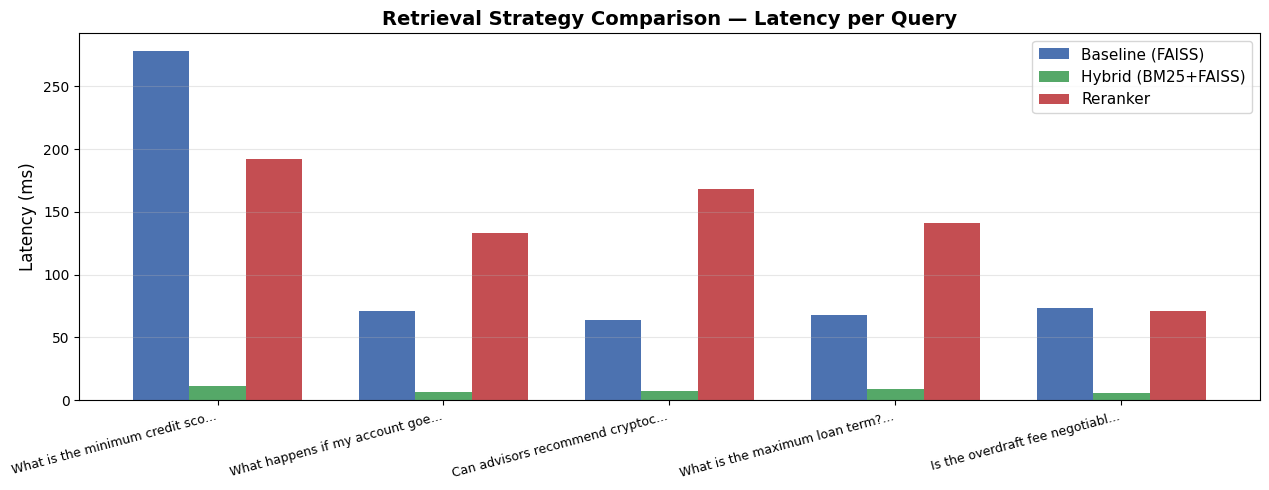

Chart saved ✓


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

labels = [r['Query'][:30] + '...' for r in results]
baseline_times = [r['Baseline ms'] for r in results]
hybrid_times = [r['Hybrid ms'] for r in results]
rerank_times = [r['Rerank ms'] for r in results]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, baseline_times, width, label='Baseline (FAISS)', color='#4C72B0')
ax.bar(x,          hybrid_times,  width, label='Hybrid (BM25+FAISS)', color='#55A868')
ax.bar(x + width,  rerank_times,  width, label='Reranker', color='#C44E52')

ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Retrieval Strategy Comparison — Latency per Query', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/rag_latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [8]:
# Detailed view: what each strategy retrieves for a key query
q = 'What is the minimum credit score for a mortgage?'
print(f'Query: "{q}"')
print('='*60)

print('\n[BASELINE — FAISS only]')
for i, d in enumerate(baseline_retriever.invoke(q)[:2]):
    print(f'  {i+1}. {d.page_content}')

print('\n[HYBRID — BM25 + FAISS]')
hyb = hybrid_retriever.invoke(q)
for i, d in enumerate(hyb[:2]):
    print(f'  {i+1}. {d.page_content}')

print('\n[RERANKED — Hybrid + Cross-Encoder]')
rr = rerank(q, hyb)
for i, d in enumerate(rr[:2]):
    print(f'  {i+1}. {d.page_content}')

Query: "What is the minimum credit score for a mortgage?"

[BASELINE — FAISS only]
  1. SecureBank Internal Policy Document

Mortgage Conditions:
To qualify for a standard mortgage at SecureBank, the applicant must have a minimum credit score of 700. The maximum loan term allowed is 25 years. The standard fixed interest rate for 2026 is 5%
  2. SecureBank offers personal loans to existing customers who have maintained an active account in good standing for a minimum of 12 consecutive months. Applicants must have a minimum FICO credit score of 680, a debt-to-income (DTI) ratio not exceeding 40%, and a verifiable annual income of at least

[HYBRID — BM25 + FAISS]
  1. SecureBank Internal Policy Document

Mortgage Conditions:
To qualify for a standard mortgage at SecureBank, the applicant must have a minimum credit score of 700. The maximum loan term allowed is 25 years. The standard fixed interest rate for 2026 is 5%
  2. SecureBank offers personal loans to existing customers who have ma